# 07 · experiment/timeseries — federated AF screening on single-lead ECG (CinC 2017)

Track notebook for the `experiment/timeseries` branch. Dataset: **PhysioNet Computing in
Cardiology Challenge 2017** training set — 8,528 single-lead (lead I, AliveCor Kardia) ECG
recordings at 300 Hz, 9–60 s each (zip sha256 and access notes in `data/external/SOURCES.md`;
PhysioNet open access). Target: **atrial fibrillation vs the rest** — the GP AF-screening
question these devices are actually used for. `REFERENCE.csv` classes N/O are pooled as 0,
the 284 `~` (noisy) recordings are dropped → 8,244 rows, AF prevalence 0.0895. Kept binary so
the repo's single model class (logistic regression, CLAUDE.md rule 2) and the dual-level
imbalanced-data metrics (rule 5) apply unchanged.

Features, per `data/external/ecg_cinc2017_to_clinics.py` (numpy/scipy only — no DSP
dependencies): a 300-bin waveform block profile (`w0000`–`w0299`, resample to 6,000 points +
block means) plus nine amplitude/spectral statistics (`amp_*`, `dom_freq_hz`,
`dom_power_share`, `spec_entropy` over 0.5–40 Hz). Federation is simulated: 10 Dirichlet
label-skewed pseudo-practices (α = 0.5, accepted draw seed 48 under the ≥5-positives-per-clinic
guard — see `data/clinics_ecg/suite_meta.json`).

Prerequisites (once per clone; payloads are gitignored): `uv run python -m
data.external.ecg_cinc2017_to_clinics` after unzipping per SOURCES.md.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent  # nbconvert executes with cwd=notebooks/
CLINICS = ROOT / 'data/clinics_ecg'
RAW = ROOT / 'data/external/ecg_cinc2017/training2017'
assert CLINICS.exists(), 'run: uv run python -m data.external.ecg_cinc2017_to_clinics'

meta = json.loads((CLINICS / 'suite_meta.json').read_text())
roster = pd.DataFrame(meta['clinics']).set_index('name')[['n', 'af_rate']]
print(meta['source'])
print('target:', meta['label'])
print('pooled prevalence:', meta['prevalence'], ' over', meta['n_recordings'], 'recordings',
      '(dropped noisy:', meta['n_dropped_noisy'], ')\n')
print(roster.to_string())

PhysioNet CinC Challenge 2017 v1.0.0 (single-lead ECG, AliveCor Kardia)
target: afib = REFERENCE 'A' (binary; N/O pooled as 0; '~' noisy dropped)
pooled prevalence: 0.0895  over 8244 recordings (dropped noisy: 284 )

             n  af_rate
name                   
shard-00   102   0.8431
shard-01  1519   0.0046
shard-02   114   0.3772
shard-03  3063   0.0235
shard-04    69   0.2174
shard-05   367   0.7984
shard-06   475   0.0189
shard-07   409   0.2078
shard-08   382   0.3089
shard-09  1744   0.0057


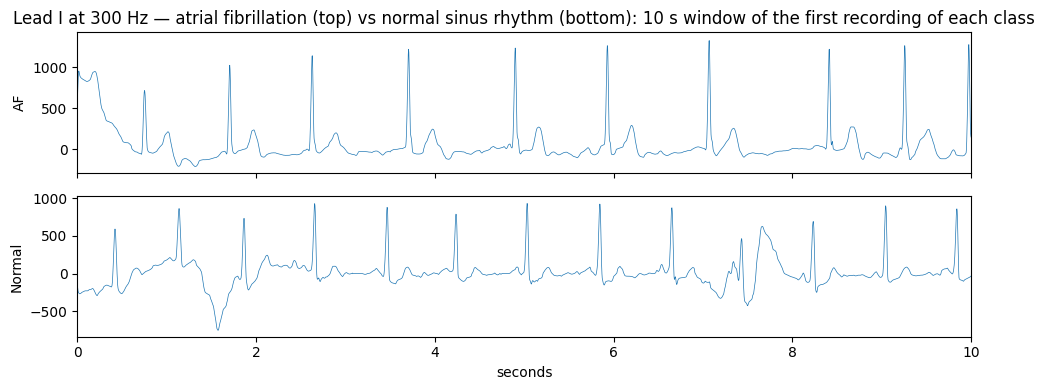

In [2]:
refs = pd.read_csv(RAW / 'REFERENCE.csv', header=None, names=['record', 'ref'])
picks = {c: refs.loc[refs['ref'] == c, 'record'].iloc[0] for c in ['A', 'N']}
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ax, (c, rec) in zip(axes, picks.items()):
    x = scipy.io.loadmat(RAW / (rec + '.mat'))['val'].ravel()
    t = np.arange(len(x)) / 300.0
    ax.plot(t, x, lw=0.5)
    ax.set_xlim(0, 10)
    ax.set_ylabel({'A': 'AF', 'N': 'Normal'}[c])
axes[0].set_title('Lead I at 300 Hz — atrial fibrillation (top) vs normal sinus rhythm (bottom): '
                  '10 s window of the first recording of each class')
axes[1].set_xlabel('seconds')
plt.tight_layout()
plt.show()

In [3]:
pooled = pd.read_csv(CLINICS / 'all_clinics.csv')
cols = ['amp_std', 'amp_skew', 'amp_kurt', 'dom_freq_hz', 'dom_power_share', 'spec_entropy']
signal = pooled.groupby('afib')[cols].mean().round(3)
signal.index = ['non-AF (N/O)', 'AF']
print('Per-class feature means (the signal the federated logreg has to work with):')
signal

Per-class feature means (the signal the federated logreg has to work with):


,amp_std,amp_skew,amp_kurt,dom_freq_hz,dom_power_share,spec_entropy
non-AF (N/O),204.740,0.972,14.073,1.708,0.071,0.730
AF,188.531,0.997,12.761,2.194,0.047,0.781


In [4]:
from simulate import run_simulation

history = run_simulation(num_practices=10, num_rounds=15, quiet=True,
                         clinics_dir=str(CLINICS))
curve = pd.DataFrame(history)[['auc', 'auc_worst', 'sensitivity', 'sensitivity_worst']]
curve.index.name = 'round'
curve.index = curve.index + 1
curve.round(3)

Flower FedAvg (in-process) | model=logreg source=on-disk clinics (10 practices) rounds=15
----------------------------------------------------------------


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


...

  round 10: AUROC=0.610 (worst practice 0.565)  sensitivity=0.150
  round 11: AUROC=0.612 (worst practice 0.567)  sensitivity=0.121
  round 12: AUROC=0.619 (worst practice 0.577)  sensitivity=0.121
  round 13: AUROC=0.624 (worst practice 0.560)  sensitivity=0.310


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


  round 14: AUROC=0.631 (worst practice 0.537)  sensitivity=0.190
  round 15: AUROC=0.649 (worst practice 0.563)  sensitivity=0.274


,auc,auc_worst,sensitivity,sensitivity_worst
round,,,,
1,0.516,0.476,0.511,0.333
2,0.495,0.249,0.408,0.000
3,0.589,0.532,0.421,0.222
4,0.627,0.573,0.209,0.000
5,0.560,0.443,0.328,0.000
6,0.604,0.548,0.185,0.000
7,0.614,0.564,0.227,0.000
8,0.526,0.363,0.184,0.000
9,0.607,0.569,0.214,0.000


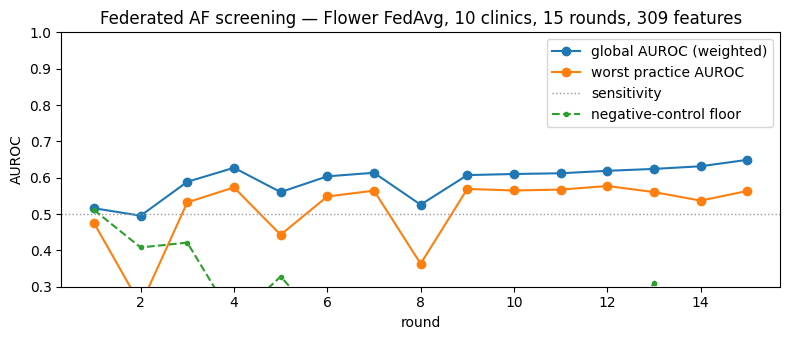

round 15: AUROC 0.649 | worst practice 0.563 | sensitivity 0.274


In [5]:
ax = curve[['auc', 'auc_worst']].plot(figsize=(8, 3.5), marker='o', ylim=(0.3, 1.0),
    title='Federated AF screening — Flower FedAvg, 10 clinics, 15 rounds, 309 features',
    ylabel='AUROC')
ax.axhline(0.5, color='0.6', ls=':', lw=1)
curve['sensitivity'].plot(ax=ax, ls='--', color='tab:green', marker='.')
ax.legend(['global AUROC (weighted)', 'worst practice AUROC', 'sensitivity',
           'negative-control floor'])
plt.tight_layout()
plt.show()
final = curve.iloc[-1]
print('round 15: AUROC %.3f | worst practice %.3f | sensitivity %.3f'
      % (final['auc'], final['auc_worst'], final['sensitivity']))

## State of the track (measured in this notebook, seed 42, 15 rounds)

- **Signal is real but modest**: global AUROC climbs into the 0.63–0.65 band against the 0.5
  floor, worst practice ~0.56. The block-profile + spectral feature cut separates AF from
  organized rhythm only coarsely — the class-mean table above shows the usable axes
  (`amp_kurt`, `dom_power_share`, `spec_entropy` move the most).
- **Sensitivity at the 0.5 threshold is low** and unstable under class-balanced sample
  weights — a calibration/threshold artifact as much as an accuracy limit. First TODO: report
  thresholded sensitivity at a fixed target AUROC operating point rather than at 0.5, per
  rule 5's sensitivity-first reading of imbalanced tasks.
- **Next protocol work on this branch**: band-limit the profile (most AF discriminability is
  sub-50 Hz rhythm irregularity, not amplitude), more local epochs per round, FedProx μ
  against the skewed shards (two clinics are >30% AF, three are <2%).
- **Deliberately out of scope**: the 4-class rhythm label (N/A/O/~) — needs the consortium's
  multi-class decision (rule 2 + `_CLASSES` in models/logreg.py are binary today).
- No protected attributes exist at this payload level (one recording per subject, no site
  keys), so the T2.5 fairness audit does not apply; the privacy machinery applies to the
  310-parameter weight vector with unchanged mechanism, subject to the same sqrt(p)
  noise-to-signal scaling noted in notebook 06.